# Laterality Feature Analysis

Analyze morphometry feature distributions by bilateral vs unilateral.
Requires `features_with_metadata.csv` with a `laterality` column (from `build_features_with_metadata.py` with `--excel-metadata`).

## 1. Setup

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu

plt.rcParams["figure.dpi"] = 150
sns.set(context="talk", style="whitegrid")

REPORT_DIR = Path()
FEATURES_PATH = REPORT_DIR / "features_with_metadata.csv"
TABLES_DIR = REPORT_DIR / "tables"
FIGS_DIR = REPORT_DIR / "figs"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)


def savetables(df: pd.DataFrame, path: str) -> None:
    """Write DataFrame to CSV, creating parent directories if needed."""
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

## 2. Load Data and Filter by Laterality

In [9]:
features_df = pd.read_csv(FEATURES_PATH)
print(f"Loaded {len(features_df)} rows from {FEATURES_PATH}")

if "laterality" not in features_df.columns:
    raise ValueError(
        "features_with_metadata.csv has no 'laterality' column. "
        "Run: python graph_extraction/analysis/build_features_with_metadata.py --morphometry-dir ... --excel-metadata ..."
    )

df_lat = features_df[features_df["laterality"].isin(["unilateral", "bilateral"])].copy()
print(f"Rows with known laterality: {len(df_lat)} (unilateral + bilateral)")

Loaded 1442 rows from features_with_metadata.csv
Rows with known laterality: 1441 (unilateral + bilateral)


## 3. Count Summaries

In [10]:
lat_counts = (
    df_lat["laterality"].value_counts().rename_axis("laterality").reset_index(name="n")
)
lat_counts["percent"] = (lat_counts["n"] / lat_counts["n"].sum() * 100).round(1)
print(lat_counts.to_string(index=False))
savetables(lat_counts, str(TABLES_DIR / "laterality_counts.csv"))

if "dataset" in df_lat.columns:
    cts = pd.crosstab(df_lat["laterality"], df_lat["dataset"])
    print("\nBy dataset:")
    print(cts)

laterality    n  percent
unilateral 1008     70.0
 bilateral  433     30.0

By dataset:
dataset     DUKE  ISPY1  ISPY2  NACT
laterality                          
bilateral    257      4    172     0
unilateral     0    140    806    62


## 4. Feature Selection for Distribution Analysis

In [11]:
MORPHO_KEYS = ["radius", "length", "tortuosity", "curvature", "volume"]
morpho_cols = [
    c
    for c in df_lat.columns
    if any(k in c.lower() for k in MORPHO_KEYS)
    and c not in ["case_id", "laterality"]
    and df_lat[c].dtype in ["float64", "int64"]
]
# Prefer aggregate means
prefer_mean = [c for c in morpho_cols if "__mean" in c or "mean__" in c]
other = [c for c in morpho_cols if c not in prefer_mean]
morpho_cols = prefer_mean[:12] + other[:8]  # limit for readability
print(f"Selected {len(morpho_cols)} morphometry features")

Selected 20 morphometry features


## 5. Feature Distributions by Laterality

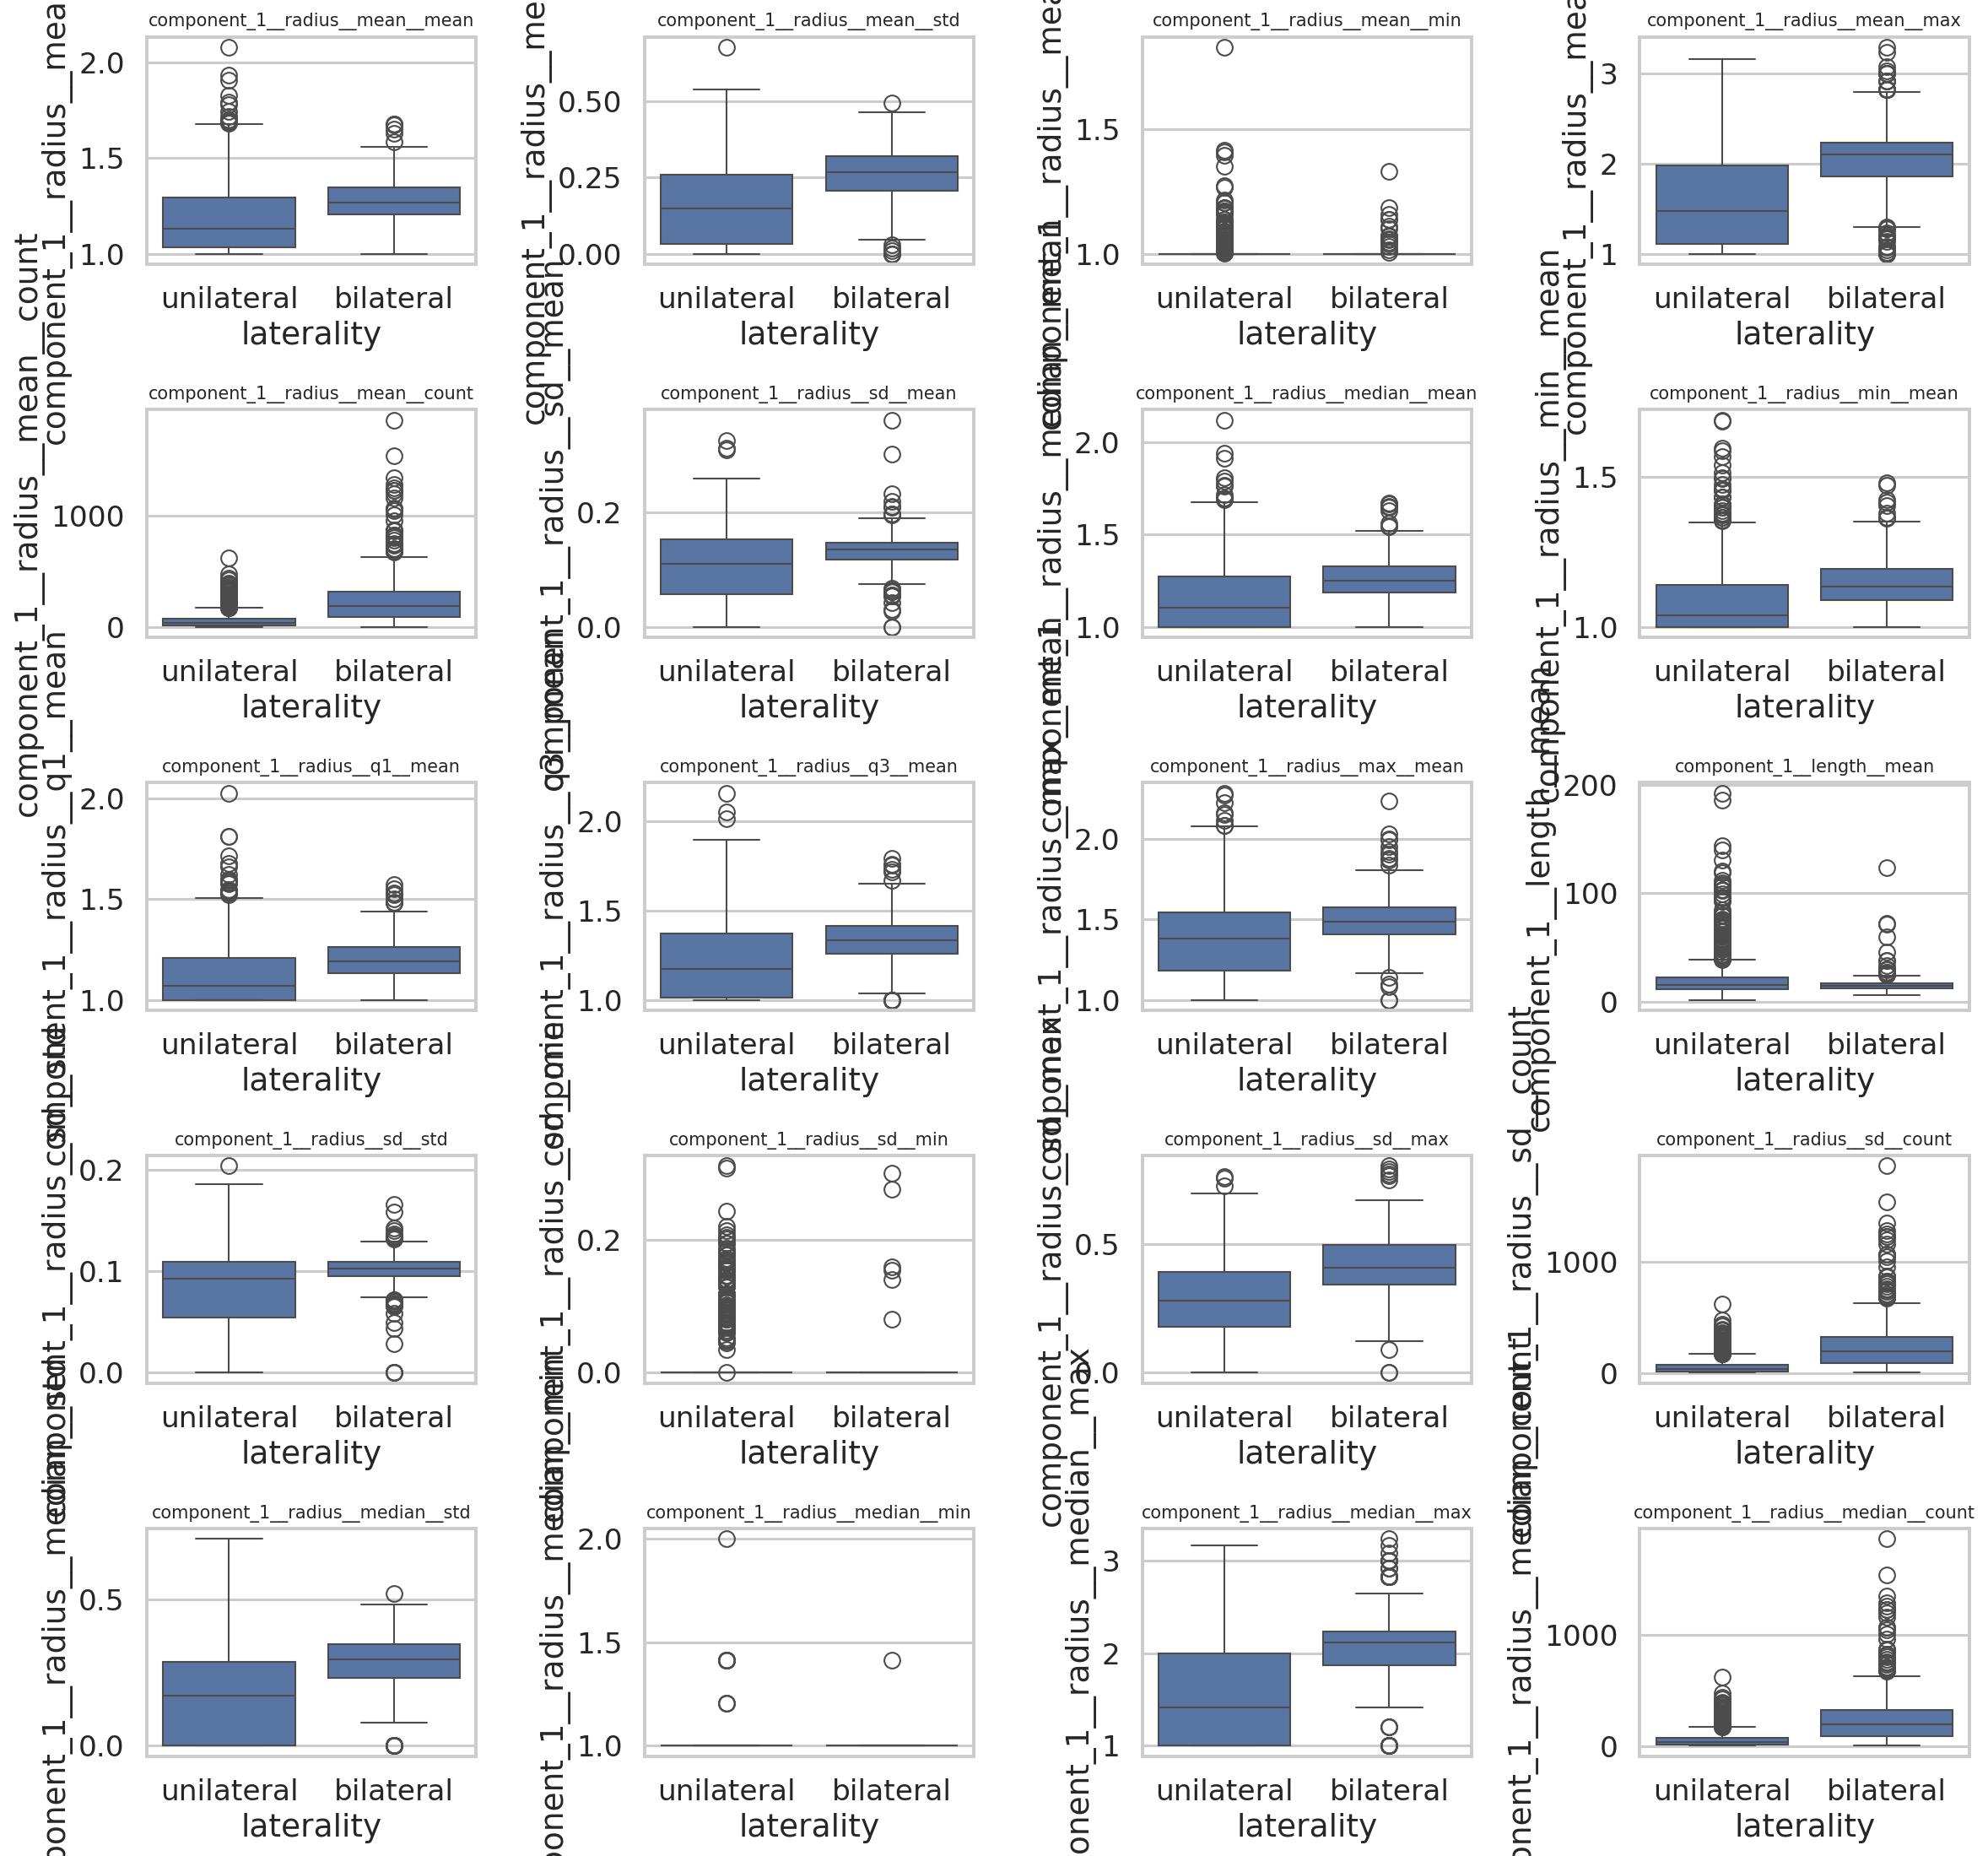

In [ ]:
MAX_TITLE_LEN = 50
n_feat = len(morpho_cols)
n_cols = 4
n_rows = (n_feat + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 6 * n_rows))
axes = np.atleast_2d(axes)
for i, col in enumerate(morpho_cols):
    ax = axes.flat[i]
    sns.boxplot(
        data=df_lat, x="laterality", y=col, order=["unilateral", "bilateral"], ax=ax
    )
    ax.set_title(
        col[:MAX_TITLE_LEN] + ("..." if len(col) > MAX_TITLE_LEN else ""), fontsize=10
    )
for j in range(i + 1, axes.size):
    axes.flat[j].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS_DIR / "laterality_feature_boxplots.png", bbox_inches="tight", dpi=200)
plt.show()

## 6. Summary Stats and Mann-Whitney U Tests

In [13]:
MIN_SAMPLE_SIZE = 2
uni = df_lat[df_lat["laterality"] == "unilateral"]
bil = df_lat[df_lat["laterality"] == "bilateral"]

rows = []
for col in morpho_cols:
    u_vals = uni[col].dropna()
    b_vals = bil[col].dropna()
    if len(u_vals) < MIN_SAMPLE_SIZE or len(b_vals) < MIN_SAMPLE_SIZE:
        continue
    stat, pval = mannwhitneyu(u_vals, b_vals, alternative="two-sided")
    rows.append(
        {
            "feature": col,
            "unilateral_mean": u_vals.mean(),
            "unilateral_std": u_vals.std(),
            "bilateral_mean": b_vals.mean(),
            "bilateral_std": b_vals.std(),
            "mannwhitney_p": pval,
        }
    )

stats_df = pd.DataFrame(rows)
stats_df = stats_df.sort_values("mannwhitney_p")
print(stats_df.to_string(index=False))
savetables(stats_df, str(TABLES_DIR / "laterality_feature_stats.csv"))

                           feature  unilateral_mean  unilateral_std  bilateral_mean  bilateral_std  mannwhitney_p
  component_1__radius__mean__count        59.238095       71.331045      260.314088     259.236724   3.679750e-98
    component_1__radius__sd__count        59.238095       71.331045      260.314088     259.236724   3.679750e-98
component_1__radius__median__count        59.238095       71.331045      260.314088     259.236724   3.679750e-98
  component_1__radius__median__max         1.569978        0.497975        2.061394       0.405119   3.924059e-63
    component_1__radius__mean__max         1.574301        0.481126        2.051078       0.399892   2.278756e-62
      component_1__radius__sd__max         0.272803        0.159721        0.409805       0.118559   5.769712e-51
    component_1__radius__mean__std         0.160163        0.129188        0.260712       0.089617   1.109436e-45
  component_1__radius__median__std         0.172389        0.143575        0.284441     

## 7. Optional: PCA by Laterality

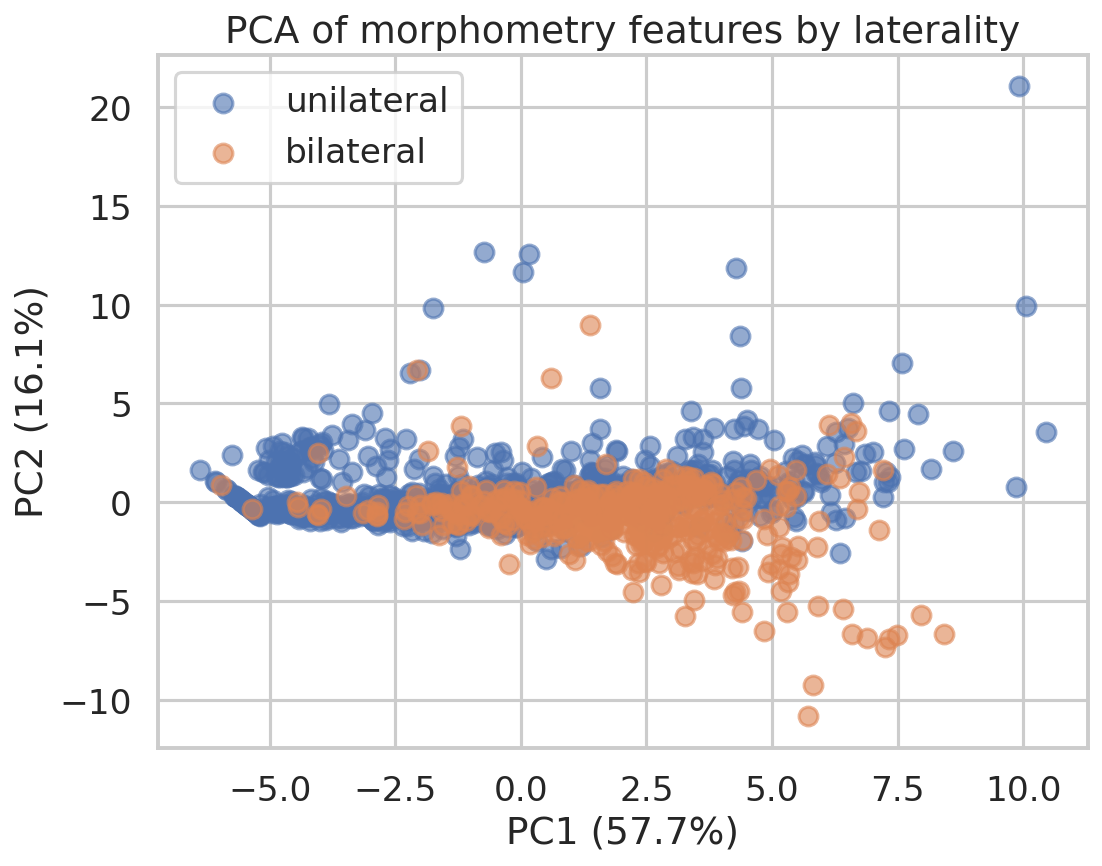

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df_lat[morpho_cols].fillna(0.0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for lat in ["unilateral", "bilateral"]:
    mask = df_lat["laterality"] == lat
    plt.scatter(coords[mask, 0], coords[mask, 1], label=lat, alpha=0.6)
plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
plt.legend()
plt.title("PCA of morphometry features by laterality")
plt.savefig(FIGS_DIR / "laterality_pca.png", bbox_inches="tight", dpi=200)
plt.show()